---
title: "Practice Activity 4"
format:
    html:
        embed-resources: true
---


# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [1]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
import pandas as pd

url = "https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv"

emails = pd.read_csv(url)

corpus = emails["body"].dropna()

corpus.head()

,body
0,we invoiced mirant americas for deal 705989 an...
1,because the payback was done for october 2001 ...
2,"for december 1999 , since the volumes for tran..."
3,i would think that the first contract should g...
4,welcome to the aol instant messenger ( sm ) se...


2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


**I would remove missing emails, lowercase the text, and remove punctuation, numbers, and common stop words. Split each email into words. Then make a table with one row per email and one column per unique word, where each value is that word’s count in the email.**

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [2]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
tf_matrix = vectorizer.fit_transform(corpus)

tf_df = pd.DataFrame(
    tf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tf_df.head()

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


**Document frequency is the number of emails that contain a word. IDF gives less weight to words found in many emails and more weight to rare words. TF-IDF is useful because common words are usually less informative, while words that are frequent in one email but rare overall can better help identify spam.**

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [3]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.head()

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0.0,0.106273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.096680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


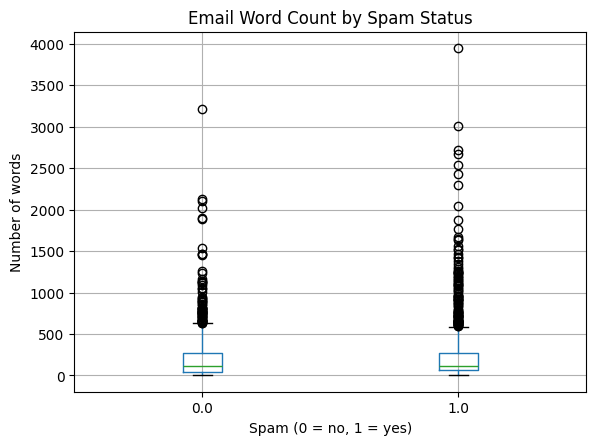

In [4]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
import matplotlib.pyplot as plt

emails_clean = emails.dropna(subset=["spam", "body"]).copy()

emails_clean["word_count"] = emails_clean["body"].str.split().str.len()

emails_clean.groupby("spam")["word_count"].describe()
emails_clean.boxplot(column="word_count", by="spam")
plt.title("Email Word Count by Spam Status")
plt.suptitle("")
plt.xlabel("Spam (0 = no, 1 = yes)")
plt.ylabel("Number of words")
plt.show()

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

**Use the labeled emails as training data. Compare the words and TF-IDF values that are most common in spam versus non-spam emails, then classify an unknown email based on whether its important words look more similar to spam or non-spam. A model like a logistic regression or Naive Bayes could learn this relationship from the TF or TF-IDF matrix and predict the 10 unknown labels.**

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [6]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_distances
import pandas as pd

vectorizer = CountVectorizer()
tf_matrix = vectorizer.fit_transform(emails["body"].fillna(""))

target_position = emails.index.get_loc(1980)
known_mask = emails["spam"].notna().to_numpy()

distances = cosine_distances(
    tf_matrix[target_position],
    tf_matrix[known_mask]
).flatten()

distance_df = pd.DataFrame({
    "email_index": emails.index[known_mask],
    "spam": emails.loc[known_mask, "spam"].values,
    "cosine_distance": distances
}).sort_values("cosine_distance")

distance_df.head()

,email_index,spam,cosine_distance
1889,1889,1.0,0.393060
1032,1032,1.0,0.398488
1376,1376,1.0,0.408606
714,714,0.0,0.414644
1110,1110,1.0,0.415807


9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [10]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
# I would classify email 1980 as spam. Its three most similar known emails are all labeled spam, including the closest email (index 1889) with a cosine distance of 0.393. This suggests its word-frequency pattern is more similar to spam emails.
distance_df.sort_values("cosine_distance").head(10)
closest_email = distance_df.iloc[0]

print("Closest email index:", closest_email["email_index"])
print("Predicted spam status:", closest_email["spam"])
print("Cosine distance:", closest_email["cosine_distance"])

,email_index,spam,cosine_distance
1889,1889,1.0,0.393060
1032,1032,1.0,0.398488
1376,1376,1.0,0.408606
714,714,0.0,0.414644
1110,1110,1.0,0.415807
26,26,0.0,0.418573
180,180,0.0,0.423172
879,879,0.0,0.424620
713,713,0.0,0.427930
139,139,0.0,0.434841


10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [8]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
# Yes, the results change.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(emails["body"].fillna(""))

tfidf_distances = cosine_distances(
    tfidf_matrix[target_position],
    tfidf_matrix[known_mask]
).flatten()

tfidf_distance_df = pd.DataFrame({
    "email_index": emails.index[known_mask],
    "spam": emails.loc[known_mask, "spam"].values,
    "cosine_distance": tfidf_distances
}).sort_values("cosine_distance")

tfidf_distance_df.head(10)

,email_index,spam,cosine_distance
1032,1032,1.0,0.755245
1977,1977,1.0,0.780917
48,48,0.0,0.787975
1689,1689,1.0,0.790205
1796,1796,1.0,0.795094
180,180,0.0,0.797415
586,586,0.0,0.798537
1376,1376,1.0,0.799377
279,279,0.0,0.799969
1021,1021,1.0,0.801259


11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [11]:
# ENTER YOUR CODE HERE. FEEL FREE TO ADD CELLS
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

unknown_mask = emails["spam"].isna().to_numpy()
known_mask = emails["spam"].notna().to_numpy()

all_distances = cosine_distances(
    tf_matrix[unknown_mask],
    tf_matrix[known_mask]
)

closest_positions = all_distances.argmin(axis=1)
known_spam = emails.loc[known_mask, "spam"].to_numpy()

guesses = pd.DataFrame({
    "email_index": emails.index[unknown_mask],
    "predicted_spam": known_spam[closest_positions],
    "closest_distance": all_distances.min(axis=1)
})

guesses

,email_index,predicted_spam,closest_distance
0,1980,1.0,0.393060
1,1981,0.0,0.570331
2,1982,0.0,0.427528
3,1983,0.0,0.264059
4,1984,0.0,0.332876
5,1985,1.0,0.393782
6,1986,1.0,0.682457
7,1987,1.0,0.485294
8,1988,1.0,0.242536
9,1989,0.0,0.823936
